![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# XAI for Transformers: <Method's title>


This Notebook shows ... 

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-transformer/2-Tutorial_AttentionMaps_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
A folder has been created in your Drive, and you can navigate it through the lefthand panel in Colab. You might also receive an email that informs you about the access on your Google Drive.

In [ ]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [ ]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [ ]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-transformer.txt
# %cd xai-for-transformer

### Imports

In [1]:
import os
import torch
import transformers

import zipfile
import requests
import datasets
import pandas as pd

import shap

# Select the best available device: NVIDIA GPU (CUDA), Apple Silicon GPU (MPS), or CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


---

## Data and Model Loading: The Emotions Dataset

In this notebook, we will work with the **Emotion dataset**, containing English text samples labelled with one of six emotions: **sadness, joy, love, anger, fear,** or **surprise**. Each row consists of a short text and its corresponding emotion label. We will use the predefined dataset split, which contains **16,000 training samples, 2,000 validation samples, and 2,000 test samples**. Our goal is to **predict the emotion expressed in a text** and use SHAP to investigate which words and tokens contribute most strongly to the model's predictions.

**ADD IMAGE HERE**

In the notebook [*1-Tutorial_Transformer_Model.ipynb*](./1-Tutorial_Transformer_Model.ipynb), we introduced the Transformer architecture and the DistilBERT model used throughout this tutorial.

In [2]:
# Fine-tuned DistilBERT emotion weights, hosted as a GitHub Release asset.
# NOTE: the download link becomes active once the weights Release is published.
url = "https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/releases/download/distilbert-emotion-weights/distilbert_emotion_weights.zip"

weights_path = "../data/distilbert-emotion"
zip_path = "../data/distilbert_emotion_weights.zip"
os.makedirs("../data", exist_ok=True)

if not os.path.exists(weights_path):
    # Reuse a local zip if it is already there (e.g. shared for testing),
    # otherwise download it from the Release.
    if not os.path.exists(zip_path):
        with open(zip_path, "wb") as f:
            f.write(requests.get(url).content)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("../data/")

model = transformers.AutoModelForSequenceClassification.from_pretrained(weights_path).to(device)
tokenizer = transformers.AutoTokenizer.from_pretrained(weights_path)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [3]:
# load the emotion dataset
dataset = datasets.load_dataset("dair-ai/emotion", split="train")
data = pd.DataFrame({"text": dataset["text"], "emotion": dataset["label"]})

Note: we have the following labels in the dataset - `{0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}`

## Now, what does my model think is important in the data?

### SHapley Additive exPlanations (SHAP)

**We prepared a small [Introduction to SHAP](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap.html) for you, to help you understand how this method works.**

*Note: we provide all references [here](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap.html#references).*

<font color='green'>

#### Question 1: xxx?

<font color='grey'>

#### Your Answer: 
xxx

<font color='green'>

#### Question 2: xxx?

<font color='grey'>

#### Your Answer: 
xxx

Now, let's use SHAP to gain insights into our transformer model. The `shap.Explainer()` class estimates **Shapley values** to explain the predictions of machine learning models. Depending on the model type and input modality, SHAP automatically selects an appropriate explainer. For transformer-based text models, commonly used explainers include:

| Explainer | Comments | 
|-----------|----------|  
| [PartitionExplainer](https://shap.readthedocs.io/en/latest/generated/shap.PartitionExplainer.html) | Efficiently approximates Shapley values by hierarchically grouping tokens. The standard choice for transformer-based NLP models. |
| [PermutationExplainer](https://shap.readthedocs.io/en/latest/generated/shap.PermutationExplainer.html) | Model-agnostic and applicable to any transformer model, but requires substantially more model evaluations than `PartitionExplainer`. |
| [SamplingExplainer](https://shap.readthedocs.io/en/latest/generated/shap.SamplingExplainer.html) | Monte Carlo approximation of Shapley values. More efficient than `KernelExplainer`, but generally less suitable than `PartitionExplainer` for text. |
| [KernelExplainer](https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html) | Fully model-agnostic, but computationally expensive for text because each token is treated as a feature. Primarily useful for small examples. |

All of the above estimate Shapley values using different approximation strategies. In this course, we will focus on `shap.PartitionExplainer()`, which is the recommended explainer for transformer-based text models. It efficiently estimates token-level Shapley values while requiring far fewer model evaluations than the fully model-agnostic approaches. You can read more about each explainer in the [SHAP API](https://shap.readthedocs.io/en/latest/api.html#explainers).

**PartitionExplainer**

**ADD IMAGE HERE**

Text inputs often consist of tens or hundreds of tokens, making the exact computation of Shapley values computationally infeasible. `PartitionExplainer` addresses this challenge by recursively grouping tokens into a hierarchical structure and computing contributions for groups of tokens rather than considering every possible subset individually. This reduces the computational complexity while still providing faithful approximations of the Shapley values.

For transformer models such as DistilBERT, `PartitionExplainer` is typically combined with a **text masker** (`shap.maskers.Text`), which creates perturbed versions of the input sentence by masking selected tokens. The model is then evaluated on these perturbed texts, and the changes in the predicted probabilities are used to estimate the contribution of each token. Tokens with positive SHAP values increase the predicted probability of the selected emotion, whereas tokens with negative SHAP values decrease it.

In this notebook, we will use `shap.Explainer()` together with a text masker. SHAP automatically recognizes the text model and constructs a `PartitionExplainer` internally. Rather than focusing on the underlying approximation algorithm, we will concentrate on interpreting the resulting token attributions. For a more detailed discussion of `PartitionExplainer` and the approximation of Shapley values, we refer to the SHAP documentation and the book *Interpreting Machine Learning Models With SHAP* ([Molnar, 2022](https://leanpub.com/shap)).

Emotion classification multiclass example

This notebook demonstrates how to use the Partition explainer for a multiclass text classification scenario. Once the SHAP values are computed for a set of sentences we then visualize feature attributions towards individual classes. The text classifcation model we use is BERT fine-tuned on an emotion dataset to classify a sentence among six classes: joy, sadness, anger, fear, love and surprise.

Build a transformers pipline

Note that we have set return_all_scores=True for the pipeline so we can observe the model’s behavior for all classes, not just the top output.

In [4]:
# build a pipeline object to do predictions
pred = transformers.pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0,
    return_all_scores=True,
)

Create an explainer for the pipeline

A transformers pipeline object can be passed directly to shap.Explainer, which will then wrap the pipeline model as a shap.models.TransformersPipeline model and the pipeline tokenizer as a shap.maskers.Text masker.

In [7]:
masker = shap.maskers.Text(tokenizer)
explainer = shap.PartitionExplainer(pred, masker)

Compute SHAP values

Explainers have the same method signature as the models they are explaining, so we just pass a list of strings for which to explain the classifications.

In [8]:
shap_values = explainer(data["text"][:3])

Visualize the impact on all the output classes

In the plots below, when you hover your mouse over an output class you get the explanation for that output class. When you click an output class name then that class remains the focus of the explanation visualization until you click another class.

The base value is what the model outputs when the entire input text is masked, while 𝑓𝑜⁢𝑢⁢𝑡⁢𝑝⁢𝑢⁢𝑡⁢𝑐⁢𝑙⁢𝑎⁢𝑠⁢𝑠⁡(𝑖⁢𝑛⁢𝑝⁢𝑢⁢𝑡⁢𝑠)
is the output of the model for the full original input. The SHAP values explain in an addive way how the impact of unmasking each word changes the model output from the base value (where the entire input is masked) to the final prediction value.

In [9]:
shap.plots.text(shap_values)

Visualize the impact on a single class

Since Explanation objects are sliceable we can slice out just a single output class to visualize the model output towards that class.

In [10]:
shap.plots.text(shap_values[:, :, "anger"])

Plotting the top words impacting a specific class

In addition to slicing, Explanation objects also support a set of reducing methods. Here we use the .mean(0) to take the average impact of all words towards the “joy” class. Note that here we are also averaging over three examples, to get a better summary you would want to use a larger portion of the dataset.

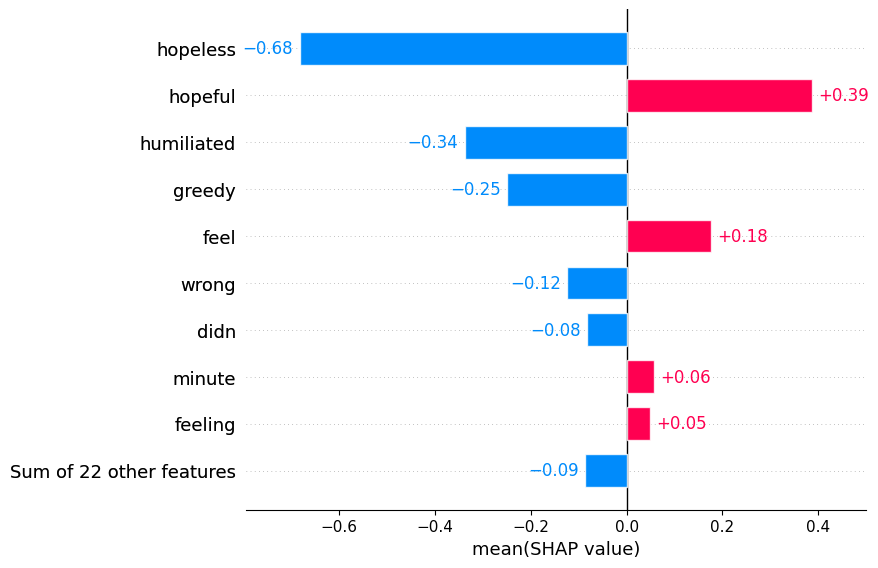

In [11]:
shap.plots.bar(shap_values[:, :, "joy"].mean(0))

In [ ]:
# we can sort the bar chart in decending order
shap.plots.bar(shap_values[:, :, "joy"].mean(0), order=shap.Explanation.argsort)

In [ ]:
# ...or acending order
shap.plots.bar(shap_values[:, :, "joy"].mean(0), order=shap.Explanation.argsort.flip)